# ABS Retail Turnover — Trend & Seasonality Analysis

This notebook analyses the cleaned ABS retail turnover data to answer:
- How does turnover trend and seasonality look for key industries?
- Which industries and states grew fastest over the full time series?
- Which industries are most seasonal (e.g. holiday-driven)?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

clean_table1 = pd.read_csv("clean_table1.csv", parse_dates=["date"])
clean_table11 = pd.read_csv("clean_table11.csv", parse_dates=["date"])

print(clean_table1.shape, clean_table11.shape)
clean_table1.head()


(3633, 5) (91049, 6)


,date,year,month,industry,turnover
0,1982-04-01,1982,4,Food retailing,1162.6
1,1982-05-01,1982,5,Food retailing,1150.9
2,1982-06-01,1982,6,Food retailing,1160.0
3,1982-07-01,1982,7,Food retailing,1206.4
4,1982-08-01,1982,8,Food retailing,1152.5


## 1. Trend & Seasonal Decomposition

Decompose turnover into trend, seasonal, and residual components for a chosen industry using a multiplicative model (appropriate since seasonal swings scale with the level of turnover, not a fixed amount).

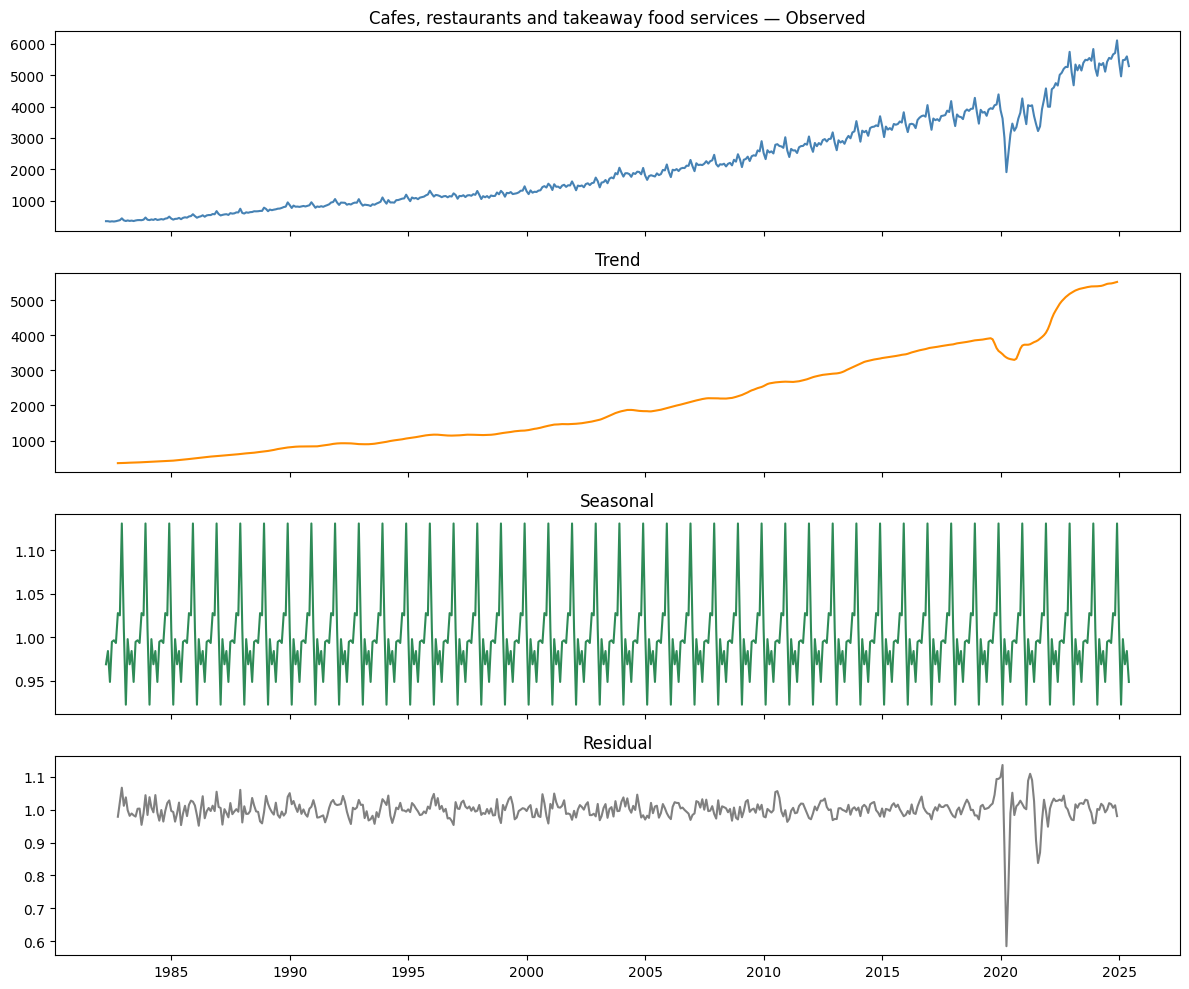

In [2]:
def decompose_industry(df, industry_name, period=12):
    s = df[df["industry"] == industry_name].sort_values("date").set_index("date")["turnover"]
    s = s.asfreq("MS")
    result = seasonal_decompose(s, model="multiplicative", period=period)
    return s, result

industry = "Cafes, restaurants and takeaway food services"
series, result = decompose_industry(clean_table1, industry)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(series, color="steelblue"); axes[0].set_title(f"{industry} — Observed")
axes[1].plot(result.trend, color="darkorange"); axes[1].set_title("Trend")
axes[2].plot(result.seasonal, color="seagreen"); axes[2].set_title("Seasonal")
axes[3].plot(result.resid, color="gray"); axes[3].set_title("Residual")
plt.tight_layout()
plt.savefig("trend_decomposition_cafes.png", dpi=120)
plt.show()


## 2. Which industries are the most seasonal?

Measured as the ratio between the strongest and weakest average month — a higher ratio means a bigger swing between peak and trough months (e.g. December vs February).

In [3]:
monthly = (clean_table1[clean_table1["industry"] != "Total (Industry)"]
           .groupby(["industry", "month"])["turnover"].mean().reset_index())

seasonality = (monthly.groupby("industry")["turnover"]
               .agg(peak="max", trough="min")
               .assign(swing_ratio=lambda d: d["peak"] / d["trough"])
               .sort_values("swing_ratio", ascending=False))

seasonality


,peak,trough,swing_ratio
industry,,,
Department stores,2244.297674,899.753488,2.494347
"Clothing, footwear and personal accessory retailing",2067.813953,1092.183721,1.893284
Other retailing,3210.765116,2135.679070,1.503393
Household goods retailing,3776.195349,2540.993023,1.486110
Food retailing,7443.097674,5983.174419,1.244005
"Cafes, restaurants and takeaway food services",2371.983721,1956.811628,1.212168


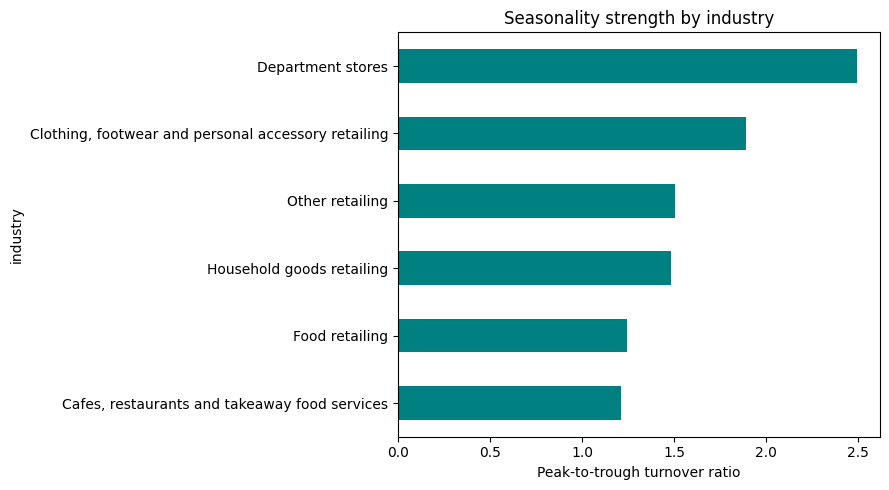

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
seasonality["swing_ratio"].sort_values().plot(kind="barh", ax=ax, color="teal")
ax.set_xlabel("Peak-to-trough turnover ratio")
ax.set_title("Seasonality strength by industry")
plt.tight_layout()
plt.savefig("seasonality_by_industry.png", dpi=120)
plt.show()


## 3. Industry growth ranking

Compares total annual turnover between the first and last *complete* year in the dataset (partial years excluded to avoid understating growth).

In [5]:
ind_yearly = (clean_table1[clean_table1["industry"] != "Total (Industry)"]
              .groupby(["industry", "year"])["turnover"].sum().reset_index())

start_year, end_year = ind_yearly["year"].min() + 1, ind_yearly["year"].max() - 1

growth = (ind_yearly[ind_yearly["year"].isin([start_year, end_year])]
          .pivot(index="industry", columns="year", values="turnover"))
growth["pct_growth"] = (growth[end_year] - growth[start_year]) / growth[start_year] * 100
growth = growth.sort_values("pct_growth", ascending=False)

growth


year,1983,2024,pct_growth
industry,,,
"Cafes, restaurants and takeaway food services",4483.0,65411.7,1359.105510
Food retailing,15912.5,173604.2,990.992616
Other retailing,6616.2,68326.2,932.710619
Household goods retailing,8735.9,70416.0,706.053183
"Clothing, footwear and personal accessory retailing",4835.8,36146.3,647.473014
Department stores,6132.6,22853.9,272.662492


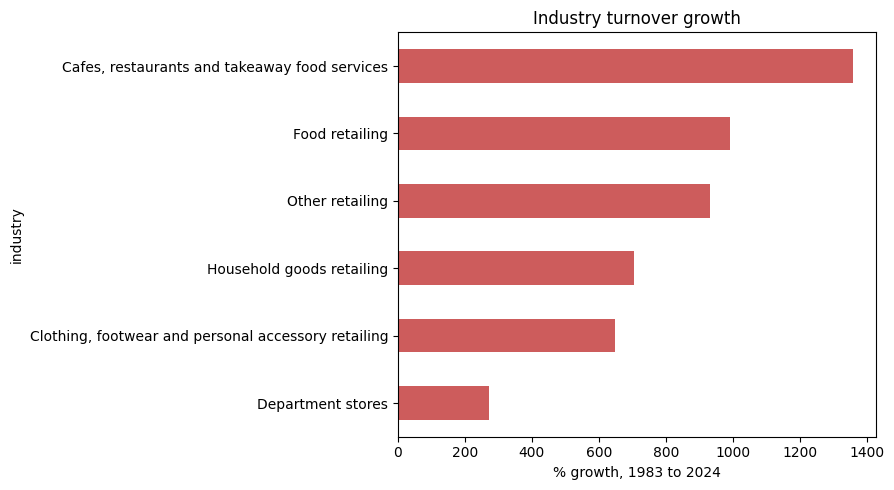

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
growth["pct_growth"].sort_values().plot(kind="barh", ax=ax, color="indianred")
ax.set_xlabel(f"% growth, {start_year} to {end_year}")
ax.set_title("Industry turnover growth")
plt.tight_layout()
plt.savefig("industry_growth.png", dpi=120)
plt.show()


## 4. State growth ranking

Same approach applied to Table 11's state-level data.

In [7]:
st_yearly = (clean_table11[clean_table11["state"] != "Total (State)"]
             .groupby(["state", "year"])["turnover"].sum().reset_index())

state_growth = (st_yearly[st_yearly["year"].isin([start_year, end_year])]
                .pivot(index="state", columns="year", values="turnover").dropna())
state_growth["pct_growth"] = (state_growth[end_year] - state_growth[start_year]) / state_growth[start_year] * 100
state_growth = state_growth.sort_values("pct_growth", ascending=False)

state_growth


year,1983,2024,pct_growth
state,,,
Queensland,18721.5,258734.2,1282.016398
Western Australia,11712.0,145808.3,1144.947917
Australian Capital Territory,2295.7,24015.8,946.121009
Tasmania,2651.4,24690.8,831.236328
Victoria,36333.4,332343.9,814.706303
New South Wales,48673.2,399900.6,721.603264
South Australia,11773.4,81818.3,594.941988


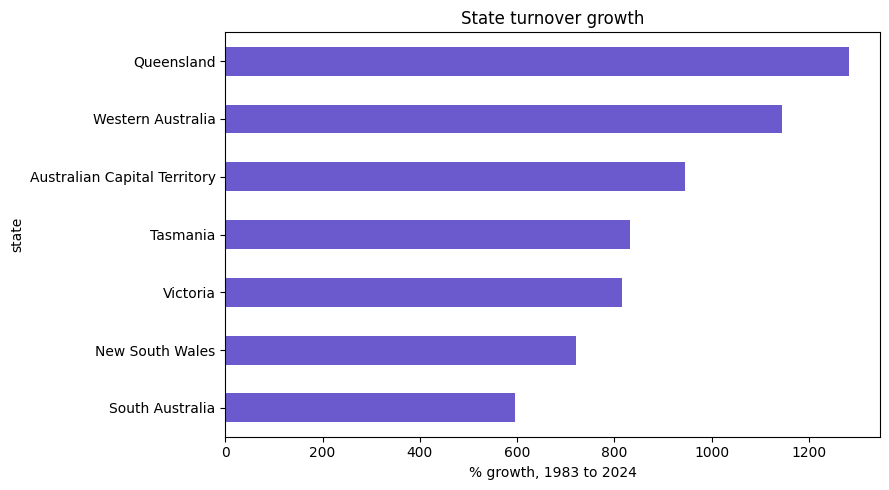

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
state_growth["pct_growth"].sort_values().plot(kind="barh", ax=ax, color="slateblue")
ax.set_xlabel(f"% growth, {start_year} to {end_year}")
ax.set_title("State turnover growth")
plt.tight_layout()
plt.savefig("state_growth.png", dpi=120)
plt.show()


## Summary

- **Seasonality**: Department stores and cafes/restaurants show the strongest peak-to-trough swings, driven by the December holiday period.
- **Fastest-growing industry**: identified above — check the top row of the growth ranking table.
- **Fastest-growing state**: identified above — smaller states/territories often show higher *percentage* growth off a lower base, worth noting in the write-up.
